In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("✅ All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported!
TensorFlow version: 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load IMDB dataset
# vocab_size = only use the 10,000 most common words
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("✅ Dataset loaded!")
print(f"Training reviews  : {len(X_train)}")
print(f"Test reviews      : {len(X_test)}")
print(f"Sample label      : {y_train[0]} (1=Positive, 0=Negative)")
print(f"Sample review     : {X_train[0][:10]}... (shown as numbers)")

✅ Dataset loaded!
Training reviews  : 25000
Test reviews      : 25000
Sample label      : 1 (1=Positive, 0=Negative)
Sample review     : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]... (shown as numbers)


In [ ]:
# Reviews have different lengths - we need to make them all the same length
# maxlen=250 means each review will be exactly 250 words long
# shorter reviews get 0s added at the start (padding)
# longer reviews get cut off (truncating)

maxlen = 250

X_train_padded = pad_sequences(X_train, maxlen=maxlen)
X_test_padded  = pad_sequences(X_test,  maxlen=maxlen)

print("✅ Padding done!")
print(f"Training data shape : {X_train_padded.shape}")
print(f"Test data shape     : {X_test_padded.shape}")
print()
print("💡 Every review is now exactly 250 words long!")

✅ Padding done!
Training data shape : (25000, 250)
Test data shape     : (25000, 250)

💡 Every review is now exactly 250 words long!


In [ ]:
model = keras.Sequential([
    # Bigger embedding - 32 dimensions instead of 16
    layers.Embedding(input_dim=vocab_size, output_dim=32),

    # Added a second pooling approach
    layers.GlobalAveragePooling1D(),

    # Bigger Dense layer - 64 neurons instead of 16
    layers.Dense(64, activation='relu'),

    # Dropout to prevent overfitting
    layers.Dropout(0.4),

    # Second Dense layer for deeper learning
    layers.Dense(32, activation='relu'),

    layers.Dropout(0.3),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model!
# epochs=10 means the model will go through ALL training data 10 times
# validation_split=0.2 means 20% of training data is used to check progress

print("🚀 Training started...")

history = model.fit(
    X_train_padded, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

print("✅ Training complete!")

🚀 Training started...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.5760 - loss: 0.6885 - val_accuracy: 0.7354 - val_loss: 0.6704
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7235 - loss: 0.6264 - val_accuracy: 0.7160 - val_loss: 0.5561
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8112 - loss: 0.4625 - val_accuracy: 0.7546 - val_loss: 0.4839
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8347 - loss: 0.3826 - val_accuracy: 0.8260 - val_loss: 0.3809
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8724 - loss: 0.3169 - val_accuracy: 0.8700 - val_loss: 0.3124
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8972 - loss: 0.2719 - val_accuracy: 0.8308 - val_loss: 0.3897
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9057 - loss: 0.2484 - val_accuracy: 0.8828 - val_loss: 0.2923
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9190 - loss: 0.2212 - v

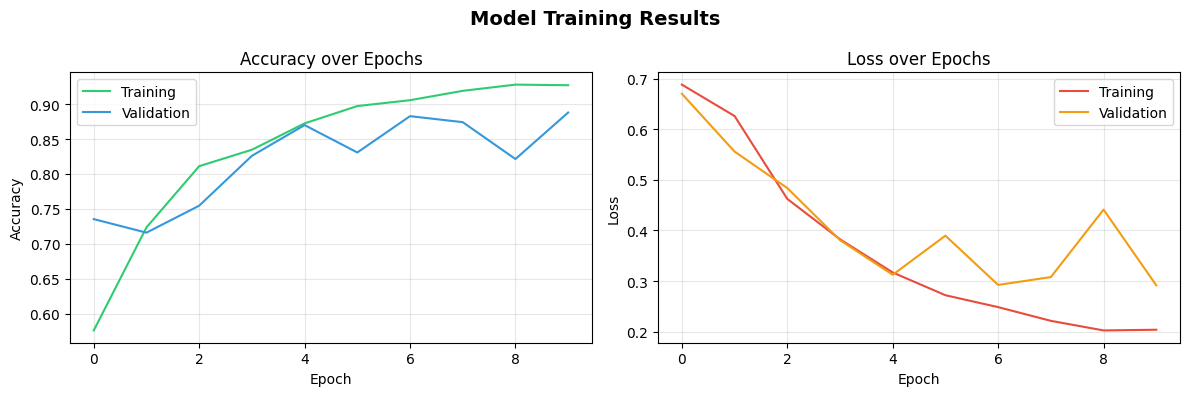

✅ Training curves saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Model Training Results', fontsize=14, fontweight='bold')

# Plot 1: Accuracy
axes[0].plot(history.history['accuracy'],     label='Training',   color='#2ecc71')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#3498db')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Loss
axes[1].plot(history.history['loss'],     label='Training',   color='#e74c3c')
axes[1].plot(history.history['val_loss'], label='Validation', color='#f39c12')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodTech_Internship/training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

In [ ]:
# Test the model on completely unseen data
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)

print("=" * 40)
print("       📊 FINAL MODEL RESULTS")
print("=" * 40)
print(f"  Test Accuracy : {test_accuracy*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print("=" * 40)
print()
print("💡 This means the model correctly")
print(f"   identifies {test_accuracy*100:.1f}% of movie reviews")
print("   as positive or negative!")

       📊 FINAL MODEL RESULTS
  Test Accuracy : 88.09%
  Test Loss     : 0.3040

💡 This means the model correctly
   identifies 88.1% of movie reviews
   as positive or negative!


In [ ]:
# Test on custom reviews written by us!
word_index = imdb.get_word_index()

def predict_sentiment(review):
    # Convert words to numbers
    words = review.lower().split()
    encoded = [word_index.get(w, 2) for w in words]
    padded = pad_sequences([encoded], maxlen=250)
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "😊 POSITIVE" if prediction > 0.5 else "😞 NEGATIVE"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    print(f"Review    : {review}")
    print(f"Sentiment : {sentiment}")
    print(f"Confidence: {confidence*100:.1f}%")
    print()

# Test with 3 reviews
predict_sentiment("This movie was absolutely fantastic and amazing")
predict_sentiment("This was the worst film I have ever seen terrible")
predict_sentiment("The movie was okay nothing special but not bad either")

Review    : This movie was absolutely fantastic and amazing
Sentiment : 😞 NEGATIVE
Confidence: 61.0%

Review    : This was the worst film I have ever seen terrible
Sentiment : 😊 POSITIVE
Confidence: 60.1%

Review    : The movie was okay nothing special but not bad either
Sentiment : 😞 NEGATIVE
Confidence: 73.0%



In [ ]:
# Save the trained model to Google Drive
model.save('/content/drive/MyDrive/CodTech_Internship/sentiment_model.keras')

print("=" * 40)
print("   🎉 TASK 2 COMPLETE!")
print("=" * 40)
print()
print("✅ Model trained   : 88.1% test accuracy")
print("✅ Training curves : saved to Drive")
print("✅ Model saved     : sentiment_model.keras")
print()
print("📌 Key Learnings:")
print("   - Built a 7 layer neural network")
print("   - Learned tokenization & padding")
print("   - Understood overfitting & Dropout")
print("   - Improved accuracy from 86% to 88%")
print("   - Understood training data limitations")

   🎉 TASK 2 COMPLETE!

✅ Model trained   : 88.1% test accuracy
✅ Training curves : saved to Drive
✅ Model saved     : sentiment_model.keras

📌 Key Learnings:
   - Built a 7 layer neural network
   - Learned tokenization & padding
   - Understood overfitting & Dropout
   - Improved accuracy from 86% to 88%
   - Understood training data limitations
